<a href="https://colab.research.google.com/github/Prakriti1103/DNN-vs-CNN-vs-CNN-Augmentation-Cifar-10-Classification/blob/main/CNN%2BAugmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPROVING THE MODEL WITH DATA AUGMENTATION

Image Augmentation is the process of artificially increasing the variations of the images in the datasets by flipping, enlarging, rotating the original images.

Augmentations also include shifting and changing the brightness of the images.

In [1]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import cifar10
from keras.utils import to_categorical

In [2]:
#Load Dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 250s 1us/step


Data Preprocessing

In [3]:
# Normalize
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Train/Validation Split

In [4]:
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

Define CNN models

In [5]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

Input_shape = X_train.shape[1:]

cnn_model = Sequential()

# Block 1
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=Input_shape))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.25))

# Block 2
cnn_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.3))

# Block 3
cnn_model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.4))

# Classifier
cnn_model.add(Flatten())

cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [6]:
from keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Image Augmentation

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

Train Model

In [8]:
history_aug = cnn_model.fit(
    datagen.flow(X_train_split, y_train_split, batch_size=64),
    epochs=25,
    validation_data=(X_val_split, y_val_split),
    verbose=1
)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 385s 604ms/step - accuracy: 0.3767 - loss: 1.8602 - val_accuracy: 0.4868 - val_loss: 1.4527
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 379s 607ms/step - accuracy: 0.5199 - loss: 1.3438 - val_accuracy: 0.5521 - val_loss: 1.2862
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 354s 563ms/step - accuracy: 0.5790 - loss: 1.1818 - val_accuracy: 0.6000 - val_loss: 1.1523
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 352s 563ms/step - accuracy: 0.6162 - loss: 1.0820 - val_accuracy: 0.6805 - val_loss: 0.9083
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 359s 574ms/step - accuracy: 0.6415 - loss: 1.0144 - val_accuracy: 0.6190 - val_loss: 1.0732
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 362s 579ms/step - accuracy: 0.6608 - loss: 0.9669 - val_accuracy: 0.6205 - val_loss: 1.0655
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 358s 573ms/step - accuracy: 0.6772 - loss: 0.9232 - val_accuracy: 0.6992 - val_loss: 0.8851
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 364s 583ms/step - accuracy: 0.6892 -

Plots Graph

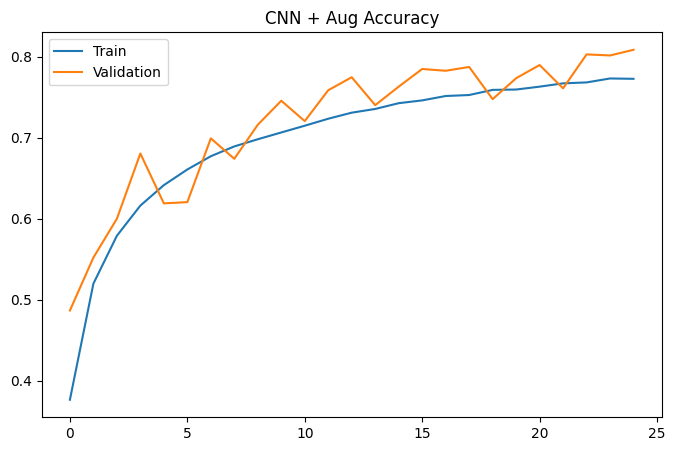

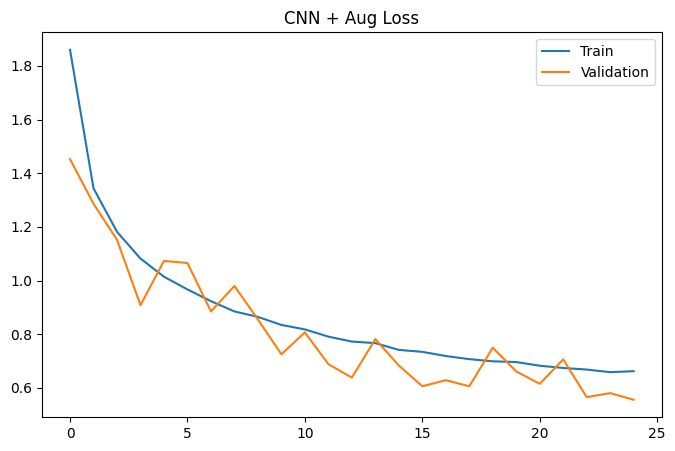

In [9]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_aug.history['accuracy'])
plt.plot(history_aug.history['val_accuracy'])
plt.title('CNN + Aug Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_aug.history['loss'])
plt.plot(history_aug.history['val_loss'])
plt.title('CNN + Aug Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Evaluate Model

In [10]:
aug_eval = cnn_model.evaluate(X_test, y_test)
print("CNN + Augmentation Test Accuracy:", aug_eval[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8058 - loss: 0.5665
CNN + Augmentation Test Accuracy: 0.8058000206947327


Predictions + Visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step


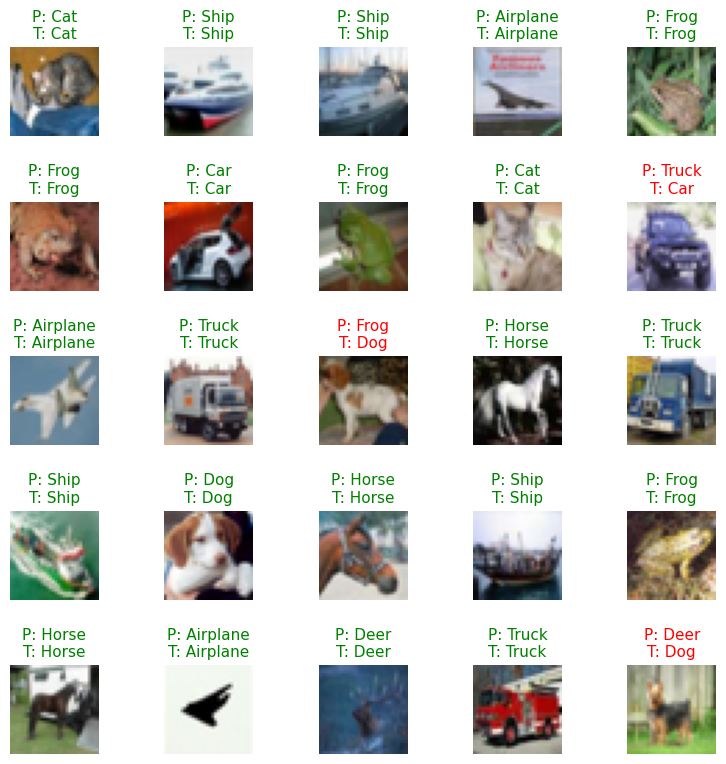

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Predict probabilities
pred_probs = cnn_model.predict(X_test)

# 🔹 Convert probabilities to class labels
pred_classes = np.argmax(pred_probs, axis=1)

# 🔹 Convert one-hot encoded true labels back to normal labels
y_true = np.argmax(y_test, axis=1)

# 🔹 Class names
class_names = [
    'Airplane', 'Car', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

# 🔹 Create grid
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize=(8,8))
axes = axes.ravel()

# 🔹 Plot images with predictions
for i in range(L * W):

    axes[i].imshow(X_test[i])

    # Green = correct prediction
    # Red = wrong prediction
    color = 'green' if pred_classes[i] == y_true[i] else 'red'

    axes[i].set_title(
        f"P: {class_names[pred_classes[i]]}\nT: {class_names[y_true[i]]}",
        fontsize=11,
        color=color
    )

    axes[i].axis('off')

# 🔹 Adjust spacing
plt.tight_layout(pad=2)

# 🔹 Show plot
plt.show()

Confusion Matrix

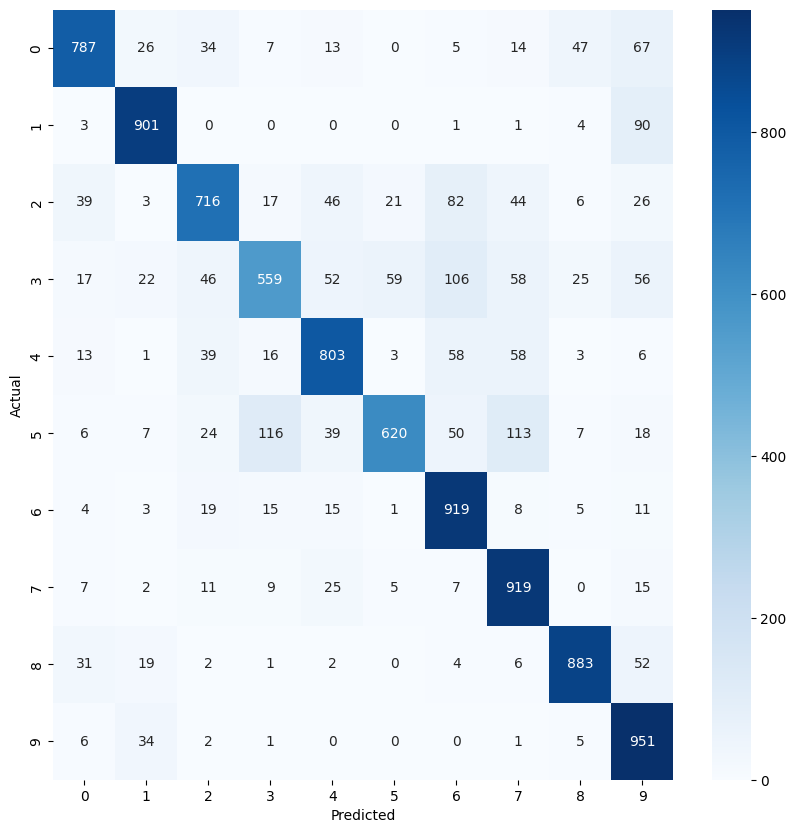

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, pred_classes)

plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()